## 1 概述

逻辑回归适用于“正/负”这种二分类问题，那多分类问题呢（比如鲍鱼数据集中按 $Sex=F/I/M$ 进行分类）？答案是 Softmax 回归。

逻辑回归是通过一个 Sigmoid 函数输出一个 0~1 之间的概率。

Softmax 回归则是利用 Softmax 函数输出一个概率分布——它会给每一个类别（ F、I、M ）都算出一个概率，且所有类别的概率之和等于 1 。

## 2 Softmax 函数

逻辑回归中，Sigmoid 函数本质是只计算“正”的概率 P ，“负”的概率隐含为 1-P ，这就像一个二选一的开关。

但当类别 K 大于 2 ，就需要一个函数可以一次性输出 K 个概率，且：
1. 每个概率都在 0 到 1 之间。
1. 所有概率之和必须等于 1 。

下面把 Sigmoid 函数进行一个变型、扩展来得到 Softmax 函数：
$$
 \frac{1}{1+e^{-z}}=\frac{e^z}{e^z+1}=\frac{e^z}{e^z+e^0}=\frac{e^{z_1}}{e^{z_1}+e^{z_2}} \implies \frac{e^{z_j}}{\sum_{k=1}^Ke^{z_k}}
$$

这里，$z_j$ 表示第 j 个类别的线性得分，某个类别的 $z_j$ 除以所有类别线性得分之和 $\sum_{k=1}^Ke^{z_k}$ ，自然就是该类别的概率。

显然，Softmax 是 Sigmoid 在多维时的自然扩展；当 K=2 时，Softmax 自动退化为逻辑回归，此时 $z_2=0$ 。

这里为什么用 $e^x$ 而不是直接用 $z_j$ ？其实原因有两个：
1. 保证非负、放大差异（单调递增且增速极快）、可导性且导数简单
1. 用带指数 $e^x$ 的 Sigmoid 函数加上 MSE 会导致梯度消失，而交叉熵就是因为用了对数 $\log$ 所以才抵消了指数的放大；Softmax 从 Sigmoid 扩展而来，继续用 $e^x$ 顺理成章。

## 3 假设函数

线性部分依旧是：$z=XW$ ，但形状不同：
- 逻辑回归: $z_{n\times 1}=X_{n\times m}W_{m\times 1}$
- Softmax : $z_{n\times K}=X_{n\times m}W_{m\times K}$

原因是要对类别进行独热编码，比如在鲍鱼数据集中 Sex 有三类，即 $K=3$ ，那么：
- 类别 1 (F) : 1 , 0, 0
- 类别 2 (I) : 0 , 1, 0
- 类别 3 (M) : 0 , 0, 1

> 独热编码用在特征时建议删除一列，但用在目标时不需要，因为目标变量不参与线性计算，而且删了会丢失该类别的误差导致权重无法更新。

那么需要分别计算三个独立的线性部分：
- $z_1=XW_F$
- $z_2=XW_I$
- $z_3=XW_M$

用矩阵合并起来一起算，那就是 $z_{n\times 3}=X_{n\times m}W_{m\times 3}$

已知，Softmax 函数 $\frac{e^{z_j}}{\sum_{k=1}^Ke^{z_k}}$ ，那么假设函数：
$$
\hat{Y}=Softmax(XW)=\frac{e^{(XW)_j}}{\sum_{k=1}^Ke^{(XW)_k}}
$$
> $\hat{Y}$ 在逻辑回归是 $n\times 1$ 的列向量，但在这里是 $n\times K$ 的矩阵

## 4 损失函数

在前面 LR 笔记中，是从交叉熵推导出逻辑回归的损失函数，但也可以这样理解：

假设，真实标签 $y$ 是 1 或 0 ，$\hat{y}$ 是预测为 1 的概率，$1-\hat{y}$ 是预测为 0 的概率，那么用“开关”规律可以写成：
$$
P=\hat{y}^y(1-\hat{y})^{1-y}
$$

取对数再取负（因为要最小化），就得到了逻辑回归的损失函数：
$$
L=-\log(\hat{y}^y(1-\hat{y})^{1-y})=-[y\log\hat{y}+(1-y)\log(1-\hat{y})]
$$

当类别不止两个，而是 K 个时，假设真实标签进行独热编码后 $Y=[y_1,y_2,...,y_K]$ ，预测的是 $\hat{Y}=[\hat{y}_1,\hat{y}_2,...,\hat{y}_K]$ ，因为不需要像逻辑回归隐含 $P_2=1-\hat{y}$ ，所以：
$$
P=\prod_{k=1}^K\hat{y}_k^{y_k}
$$

同样取对数再取负，即可得到 Softmax 回归的损失函数：
$$
L=-\log\left(\prod_{k=1}^K\hat{y}_k^{y_k}\right)=-\sum_{k=1}^K y_k\log(\hat{y}_k)
$$

## 5 代价函数

在损失函数基础上，对所有样本的损失取平均，就可以得到代价函数：
$$
J=-\frac{1}{n}\sum_{i=1}^n\sum_{k=1}^K y_{ik}\log(\hat{y}_{ik})
$$

> $y_{ik},\,\hat{y}_{ik}$ 分别表示第 i 个样本在类别 k 上的真实标签和预测值

需要将它转成矩阵形式，先看一个简单的例子：
$$
\sum_{i=1}^n\sum_{j=1}^ma_{ij}b_{ij}= \\ 
a_{11}b_{11}+a_{12}b_{12}+...+a_{1m}b_{1m}+ \\ 
a_{21}b_{21}+a_{22}b_{22}+...+a_{2m}b_{2m}+ \\
... \\
a_{n1}b_{n1}+a_{n2}b_{n2}+...+a_{nm}b_{nm}
$$

如果先定义两个矩阵：
$A_{n\times m}=\begin{pmatrix} a_{11} & a_{12} & \cdots & a_{1m} \\ a_{21} & a_{22} & \cdots & a_{2m} \\ \vdots & \vdots & \ddots & \vdots \\ a_{n1} & a_{n2} & \cdots & a_{nm} \end{pmatrix}
\quad,\quad
B_{n\times m}=\begin{pmatrix} b_{11} & b_{12} & \cdots & b_{1m} \\ b_{21} & b_{22} & \cdots & b_{2m} \\ \vdots & \vdots & \ddots & \vdots \\ b_{n1} & b_{n2} & \cdots & b_{nm} \end{pmatrix}$

那么两个矩阵对应元素相乘，这个叫哈达玛积：
$A\odot B=\begin{pmatrix} a_{11}b_{11} & a_{12}b_{12} & \cdots & a_{1m}b_{1m} \\ a_{21}b_{21} & a_{22}b_{22} & \cdots & a_{2m}b_{2m} \\ \vdots & \vdots & \ddots & \vdots \\ a_{n1}b_{n1} & a_{n2}b_{n2} & \cdots & a_{nm}b_{nm} \end{pmatrix}$

再这个结果矩阵的所有元素相加，就是双重求和了：
$\sum_{i=1}^n\sum_{j=1}^ma_{ij}b_{ij}=\text{sum}\left(A\odot B\right)$

因此，Softmax 回归的代价函数的矩阵形式就是：
$$
J(W)=-\frac{1}{n}\text{sum}\left(Y\odot\log\hat{Y}\right)
$$

## 6 计算梯度

跟 MLR 和 LR 一样，Softmax 回归的梯度计算也是：$dW=\frac{\partial J}{\partial W}=\frac{1}{n}X^T(\hat{Y}-Y)$ ，唯一的区别是 $\hat{Y}$ ：
- MLR : $\hat{Y}_{n\times 1}=XW$ ，是列向量，是每个样本的预测值组成的一串连续值 $(-\infty, +\infty)$ 。
- LR : $\hat{Y}_{n\times 1}=Sigmoid(XW)=\frac{1}{1+e^{-XW}}$ ，是列向量，是每个样本的预测值表示“正”的概率所组成的一串概率值 $(0,1)$ 。
- Softmax : $\hat{Y}_{n\times K}=Softmax(XW)=\frac{e^{(XW)_j}}{\sum_{k=1}^Ke^{(XW)_k}}$ ，是一个矩阵，每行表示一个样本可能属于 K 个类别的预测概率分布 $(0,1)$ ，行和为 1 。

## 7 数据集

针对鲍鱼数据集，需要对 Sex 特征进行独热编码，然后分为训练集和测试集：

In [ ]:
import pandas as pd
import os

names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv('./datasets/abalone/abalone.data', header=None, names=names)
out_dir = './outputs/softmax'
os.makedirs(out_dir, exist_ok=True)
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
X = df[features]    # 输入特征
y = df['Sex']       # 输出目标
# 独热编码；这里不能 drop_first=True，因为 Softmax 需要完整的 K 列
y_encoded = pd.get_dummies(y, prefix='Sex')
df_processed = pd.concat([X, y_encoded], axis=1)
df_processed.to_csv(f'{out_dir}/abalone_processed.csv', index=False)
# 打乱数据（frac=1 表示抽取 100% 的行，random_state=42 设置随机种子保证结果可复现）
df_shuffled = df_processed.sample(frac=1, random_state=42).reset_index(drop=True)
# 计算切分位置
split_idx = int(len(df_shuffled) * 0.8)
# 按位置切分
df_train = df_shuffled.iloc[:split_idx]
df_test = df_shuffled.iloc[split_idx:]
# 保存切分好的训练集和测试集
df_train.to_csv(f'{out_dir}/abalone_train.csv', index=False)
df_test.to_csv(f'{out_dir}/abalone_test.csv', index=False)
# 打印前 3 行的 Sex 独热编码列
print(df_train[['Sex_F', 'Sex_I', 'Sex_M']].head(3).to_string(index=False))

 Sex_F  Sex_I  Sex_M
 False  False   True
 False  False   True
  True  False  False


## 8 手写代码


✅ 停止于代价变化容差：第 22191 轮，代价变化 = 1.00e-07 < 1e-07

训练完成，拟合方程系数：
  Class:         Sex_F      Sex_I      Sex_M
  bias (intercept): 0.159621  -0.595445  0.435824
  Length              : -0.240824  0.788380  -0.547556
  Diameter            : 0.134951  0.040321  -0.175272
  Height              : 0.171882  -0.177357  0.005475
  Whole_weight        : 0.250546  -0.668220  0.417674
  Shucked_weight      : -0.205105  -0.151493  0.356597
  Viscera_weight      : 0.644098  -1.036955  0.392857
  Shell_weight        : 0.091904  -0.163744  0.071840
  Rings               : 0.212563  -0.465492  0.252929

Final cost J = 0.850526, total epochs = 22193

========== 测试集评估结果 ==========
准确率 (Accuracy)  : 0.5634
精确率 (Precision) : 0.5535
召回率 (Recall)    : 0.5634
F1-score           : 0.5539
混淆矩阵 (Confusion Matrix):
              Predicted Sex_F  Predicted Sex_I  Predicted Sex_M
Actual Sex_F               95               34              134
Actual Sex_I               22              202               34
Actual Sex_M 

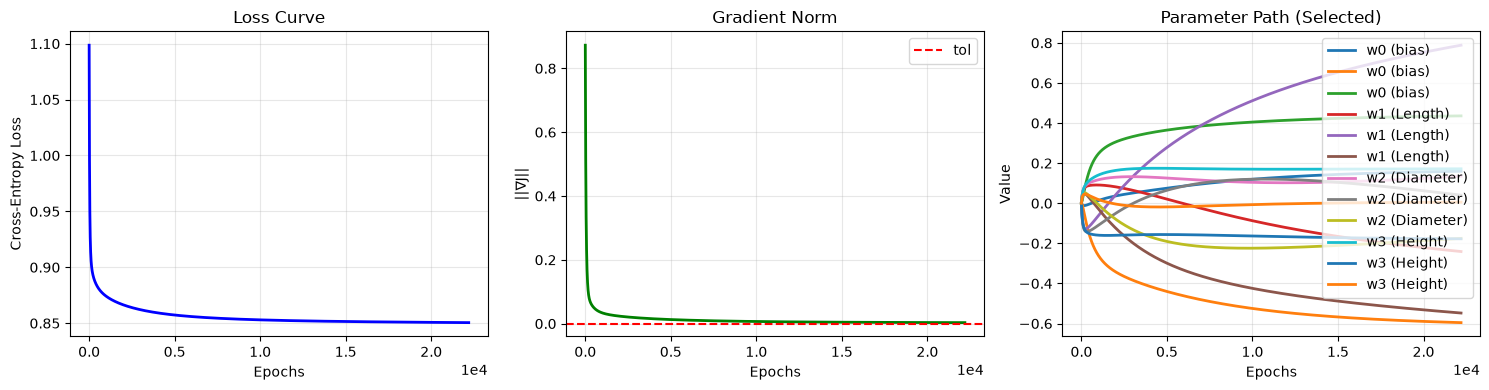

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# 超参数
W_init = np.zeros((9,3)) # 9行（偏置 + 8个特征）× 3列（M/F/I）
lr = 0.01               # 学习率
tol = 1e-7              # 容差
max_epochs = 1000000    # 最大迭代次数
# 载入训练集
df_train = pd.read_csv(f'{out_dir}/abalone_train.csv')
features = ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
targets = ['Sex_F', 'Sex_I', 'Sex_M']
# 构建特征矩阵（添加偏置列）
X_train_raw = df_train[features].values
# 数据标准化
mu = np.mean(X_train_raw, axis=0)
sigma = np.std(X_train_raw, axis=0)
sigma[sigma == 0] = 1
X_train_std = (X_train_raw - mu) / sigma
# 添加偏置列
X_train = np.c_[np.ones((X_train_std.shape[0], 1)), X_train_std]    # 左侧加全1列
# 输出目标
Y_train = df_train[targets].values
# Softmax 函数
def softmax(z):
    # 每行每个元素都减去该行的最大值，使变成小于等于零，数值平移不影响结果，能防止太大的 z 导致 e^z 溢出。
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    # 矩阵编程，一次性算出全部样本所有类别的指数值，每个元素对应softmax函数的分子 e^{z_j}
    exp_z = np.exp(z_shifted)
    # np.sum(axis=1) 是矩阵的每行求和，即每个样本的所有类别的 e^{z_k} 之和，也就是softmax函数的分母 ∑e^{z_k}
    # 分母因为加了 keepdims=True ，结果不是 (n,) 的向量，而是 (n,1) 的列向量
    # 分子 exp_z 是 (n,K) 的矩阵，(n,K)/(n,1) 则是矩阵每一列与列向量进行逐元素相除
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
# 代价函数
def cost_func(W, X, Y):
    z = X @ W
    Y_hat = softmax(z)
    # 把概率限制在 0.000...001 到 0.999...999 之间，避免出现 log(0) 或 log(1)
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)
    # 这里的 * 就是哈达玛积，对应公式的逐元素相乘；np.sum(axis=1) 是每行求和，结果是个向量；np.mean 则是向量求均值
    return -np.mean(np.sum(Y * np.log(Y_hat), axis=1))
# GD 函数
def gradient_descent(X, Y, W_init, lr, max_epochs, tol):
    W = W_init.copy()
    n = len(X)  # 样本数
    # 记录历史数据
    W_hist = [W.copy()]
    cost_hist = [cost_func(W, X, Y)]
    grad_hist = []
    param_hist = []
    # 循环进行梯度下降
    for epoch in range(max_epochs):
        Y_hat = softmax(X @ W)          # 预测
        error = Y_hat - Y               # 残差
        dW = (1/n) * X.T @ error        # 平均梯度
        grad_norm = np.linalg.norm(dW)  # 梯度范数
        grad_hist.append(grad_norm)
        # 停止条件1：梯度范数小于容差
        if grad_norm < tol:
            print(f"✅ 停止于梯度容差：第 {epoch} 轮，梯度范数 = {grad_norm:.2e} < {tol}")
            break
        # 更新参数、代价，并保存
        W_new = W - lr * dW     # 更新参数
        param_change = np.linalg.norm(W_new - W)    # 参数变化量
        param_hist.append(param_change)
        cost_new = cost_func(W_new, X, Y)   # 计算新的代价值
        W = W_new
        W_hist.append(W.copy())
        cost_hist.append(cost_new)
        # 停止条件2：参数变化量小于容差
        if param_change < tol:
            print(f"✅ 停止于参数变化容差：第 {epoch} 轮，参数变化 = {param_change:.2e} < {tol}")
            break
        # 停止条件3：代价变化量小于容差
        if abs(cost_hist[-1] - cost_hist[-2]) < tol:
            print(f"✅ 停止于代价变化容差：第 {epoch} 轮，代价变化 = {abs(cost_hist[-1] - cost_hist[-2]):.2e} < {tol}")
            break
    else:
        print(f"⚠️ 达到最大迭代次数 {max_epochs}，算法未完全收敛，请考虑调整参数。")
    # 返回数据
    return {
        'epochs': len(W_hist),
        'W_hist': W_hist,
        'cost_hist': cost_hist,
        'grad_hist': grad_hist,
        'param_hist': param_hist
    }
# 运行梯度下降
history = gradient_descent(X_train, Y_train, W_init, lr, max_epochs, tol)
# 绘制三个监测图
epochs = history['epochs']
W_hist = history['W_hist']
cost_hist = history['cost_hist']
grad_hist = history['grad_hist']
param_hist = history['param_hist']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 图1：损失下降曲线
axes[0].plot(range(epochs), cost_hist, color='blue', lw=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)
# 图2：梯度范数变化
axes[1].plot(range(len(grad_hist)), grad_hist, color='green', lw=2)
axes[1].axhline(y=tol, color='red', linestyle='--', label='tol')
axes[1].set_title('Gradient Norm')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('||∇J||')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# 图3：参数轨迹（取前四个）
W_array = np.array(W_hist)
axes[2].plot(range(epochs), W_array[:, 0], label='w0 (bias)', lw=2)
axes[2].plot(range(epochs), W_array[:, 1], label='w1 (Length)', lw=2)
axes[2].plot(range(epochs), W_array[:, 2], label='w2 (Diameter)', lw=2)
axes[2].plot(range(epochs), W_array[:, 3], label='w3 (Height)', lw=2)
axes[2].set_title('Parameter Path (Selected)')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
# 强制 X 轴刻度使用科学计数法（如 1e5, 2e5），防止数值过大时标签重叠
for ax in axes:
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.tight_layout()
plt.savefig(f'{out_dir}/gd_mlr_monitor.png', dpi=150)
# 训练结果
W_final = W_hist[-1]
print("\n训练完成，拟合方程系数：")
print("  Class:         Sex_F      Sex_I      Sex_M")
print(f"  bias (intercept): {W_final[0][0]:.6f}  {W_final[0][1]:.6f}  {W_final[0][2]:.6f}")
for name, coef in zip(features, W_final[1:]):
    print(f"  {name:20s}: {coef[0]:.6f}  {coef[1]:.6f}  {coef[2]:.6f}")
print(f"\nFinal cost J = {cost_hist[-1]:.6f}, total epochs = {epochs}")
# 在测试集用训练好的模型预测，并评估结果
df_test = pd.read_csv(f'{out_dir}/abalone_test.csv')
X_test_raw = df_test[features].values
# 数据标准化（在测试验证时要用训练集算出来的均值和标准差，因为模拟的是未来未知的新数据）
X_test_std = (X_test_raw - mu) / sigma
# 添加偏置列
X_test = np.c_[np.ones((X_test_std.shape[0], 1)), X_test_std]
Y_test = df_test[targets].values
Y_hat = softmax(X_test @ W_final)   # 预测概率
'''
在逻辑回归中这里只需要 Y_pred = (Y_hat >= 0.5).astype(int)
而这里需要将独热编码和预测概率转为类别索引，且下面计算评估指标还需要 average='weighted'
原因是：这里有多个类别，需要将多个类别的对比结果合并成一个指标
'''
Y_test_idx = np.argmax(Y_test, axis=1)
Y_pred_idx = np.argmax(Y_hat, axis=1)
# 分类评估指标
accuracy = accuracy_score(Y_test_idx, Y_pred_idx)
precision = precision_score(Y_test_idx, Y_pred_idx, average='weighted')
recall = recall_score(Y_test_idx, Y_pred_idx, average='weighted')
f1 = f1_score(Y_test_idx, Y_pred_idx, average='weighted')
conf_mat = confusion_matrix(Y_test_idx, Y_pred_idx)
class_names = ['Sex_F', 'Sex_I', 'Sex_M']
df_cm = pd.DataFrame(
    conf_mat,
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names]
)
print("\n========== 测试集评估结果 ==========")
print(f"准确率 (Accuracy)  : {accuracy:.4f}")
print(f"精确率 (Precision) : {precision:.4f}")
print(f"召回率 (Recall)    : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print("混淆矩阵 (Confusion Matrix):")
print(df_cm)
print("====================================")
plt.show()

## 9 sklearn

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np

# ========== 读取测试集（已经在手写代码中加载过，这里直接复用） ==========
# 假设 df_train, df_test, features, targets 已经存在
# 并且 mu, sigma 已经由手写代码计算好

# 准备训练数据：特征（标准化后的原始特征，不含偏置列）
X_train_std = (df_train[features].values - mu) / sigma
X_test_std = (df_test[features].values - mu) / sigma

# 目标标签：转为整数索引（0,1,2 对应 F, I, M）
# 从独热编码还原：比如 Sex_F=1 -> 0, Sex_I=1 -> 1, Sex_M=1 -> 2
y_train_idx = np.argmax(df_train[targets].values, axis=1)
y_test_idx = np.argmax(df_test[targets].values, axis=1)

# ========== 使用 sklearn 的 LogisticRegression（多分类） ==========
# multi_class='multinomial' 启用 Softmax 回归
# C=np.inf 表示无正则化（C 越大正则化越弱）
# solver='lbfgs' 适合多分类，且收敛快
# max_iter 设大一些保证收敛
model = LogisticRegression(
    solver='lbfgs',
    C=np.inf,          # 无正则化
    max_iter=10000,
    tol=1e-7
)
model.fit(X_train_std, y_train_idx)

# 预测
y_pred_idx = model.predict(X_test_std)

# ========== 评估指标 ==========
accuracy = accuracy_score(y_test_idx, y_pred_idx)
precision = precision_score(y_test_idx, y_pred_idx, average='weighted')
recall = recall_score(y_test_idx, y_pred_idx, average='weighted')
f1 = f1_score(y_test_idx, y_pred_idx, average='weighted')
conf_mat = confusion_matrix(y_test_idx, y_pred_idx)

class_names = ['Sex_F', 'Sex_I', 'Sex_M']
df_cm = pd.DataFrame(
    conf_mat,
    index=[f'Actual {name}' for name in class_names],
    columns=[f'Predicted {name}' for name in class_names]
)

print("\n========== sklearn 测试集评估结果 ==========")
print(f"准确率 (Accuracy)  : {accuracy:.4f}")
print(f"精确率 (Precision) : {precision:.4f}")
print(f"召回率 (Recall)    : {recall:.4f}")
print(f"F1-score           : {f1:.4f}")
print("混淆矩阵 (Confusion Matrix):")
print(df_cm)
print("============================================")


========== sklearn 测试集评估结果 ==========
准确率 (Accuracy)  : 0.5646
精确率 (Precision) : 0.5548
召回率 (Recall)    : 0.5646
F1-score           : 0.5547
混淆矩阵 (Confusion Matrix):
              Predicted Sex_F  Predicted Sex_I  Predicted Sex_M
Actual Sex_F               94               35              134
Actual Sex_I               21              202               35
Actual Sex_M               76               63              176


sklearn 的结果与手写代码几乎一致，可证明手写代码的正确性。